# DPT Holes

Small notebook to look at different mounting solutions for the DPT holes. 

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union


## Clover pattern

Original circle radius R: 1.000000
Clover circle radius:     0.880341
Center distance a:        0.658114
Pairwise center spacing:  1.139887

Inner cusp radii:
0.34188611699158106
0.34188611699158095
0.34188611699158117

Maximum outward distance from original circle: 0.538454
Occurs at angle: 329.99 degrees


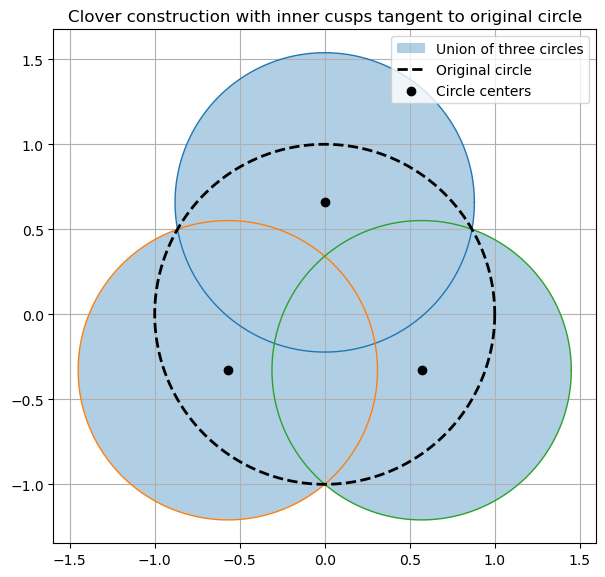

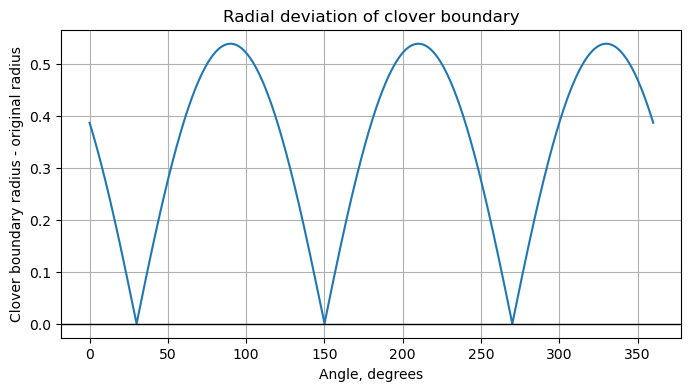


Area Results
----------------------------------------
Original circle area : 3.14158773
Clover union area    : 5.78178572
Difference           : 2.64019799
Percent difference   : 84.0402%


In [23]:

R = 1.0                 # radius of original circle
circle_radius = np.sqrt(3.1)/2     # radius of each of the three clover circles
resolution = 512

# -----------------------------
# GEOMETRY
# -----------------------------
# Three equal circles have centers on an equilateral triangle.
# The inner cusps are the inner pairwise intersections.
#
# We place the centers so that those three inner cusps lie on
# the original circle of radius R.
#
# There is one free parameter: the radius of the three clover circles.

if circle_radius <= np.sqrt(3) * R / 2:
    raise ValueError("circle_radius must be larger than sqrt(3)*R/2")

# Center distance from origin.
# This is the branch that gives a central clover-shaped void.
a = 0.5 * (R + np.sqrt(4 * circle_radius**2 - 3 * R**2))

# Centers of the three equal circles
angles = np.deg2rad([90, 210, 330])

centers = np.column_stack([
    a * np.cos(angles),
    a * np.sin(angles)
])

# Build disks
disks = [
    Point(x, y).buffer(circle_radius, resolution=resolution)
    for x, y in centers
]

clover = unary_union(disks)
original = Point(0, 0).buffer(R, resolution=resolution)

print(f"Original circle radius R: {R:.6f}")
print(f"Clover circle radius:     {circle_radius:.6f}")
print(f"Center distance a:        {a:.6f}")
print(f"Pairwise center spacing:  {np.sqrt(3)*a:.6f}")

# -----------------------------
# COMPUTE INNER CUSP POINTS
# -----------------------------

def circle_intersections(c1, c2, r):
    c1 = np.array(c1)
    c2 = np.array(c2)

    v = c2 - c1
    d = np.linalg.norm(v)

    midpoint = 0.5 * (c1 + c2)
    h = np.sqrt(r**2 - (d / 2)**2)

    u = v / d
    n = np.array([-u[1], u[0]])

    p1 = midpoint + h * n
    p2 = midpoint - h * n

    return p1, p2

cusps = []

for i, j in [(0, 1), (1, 2), (2, 0)]:
    p1, p2 = circle_intersections(
        centers[i],
        centers[j],
        circle_radius
    )

    # inner cusp is the intersection closer to the origin
    cusp = p1 if np.linalg.norm(p1) < np.linalg.norm(p2) else p2
    cusps.append(cusp)

cusps = np.array(cusps)

print()
print("Inner cusp radii:")
for p in cusps:
    print(np.linalg.norm(p))

# -----------------------------
# MAXIMUM OUTWARD RADIAL DISTANCE
# -----------------------------

theta = np.linspace(0, 2*np.pi, 3000)

radial_distance = []

for t in theta:
    direction = np.array([np.cos(t), np.sin(t)])

    lo = 0.0
    hi = a + circle_radius + R

    for _ in range(60):
        mid = 0.5 * (lo + hi)
        p = Point(*(mid * direction))

        if clover.contains(p):
            lo = mid
        else:
            hi = mid

    radial_distance.append(lo - R)

radial_distance = np.array(radial_distance)

max_distance = np.max(radial_distance)
max_angle = theta[np.argmax(radial_distance)]

print()
print(f"Maximum outward distance from original circle: {max_distance:.6f}")
print(f"Occurs at angle: {np.degrees(max_angle):.2f} degrees")

# -----------------------------
# PLOT GEOMETRY
# -----------------------------

fig, ax = plt.subplots(figsize=(7, 7))

# Clover union
x, y = clover.exterior.xy
ax.fill(x, y, alpha=0.35, label="Union of three circles")

# Individual circles
for disk in disks:
    x, y = disk.exterior.xy
    ax.plot(x, y, lw=1)

# Original circle
x, y = original.exterior.xy
ax.plot(x, y, "k--", lw=2, label="Original circle")

# Centers
ax.scatter(centers[:, 0], centers[:, 1], color="black", zorder=5, label="Circle centers")

ax.set_aspect("equal")
ax.set_title("Clover construction with inner cusps tangent to original circle")
ax.legend()
ax.grid(True)

plt.show()

# -----------------------------
# PLOT RADIAL DEVIATION
# -----------------------------

plt.figure(figsize=(8, 4))

plt.plot(np.degrees(theta), radial_distance)
plt.axhline(0, color="black", lw=1)

plt.xlabel("Angle, degrees")
plt.ylabel("Clover boundary radius - original radius")
plt.title("Radial deviation of clover boundary")
plt.grid(True)

plt.show()

# -----------------------------
# AREA CALCULATIONS
# -----------------------------

clover_area = clover.area
original_area = original.area

area_difference = clover_area - original_area
percent_difference = 100 * area_difference / original_area

print("\nArea Results")
print("-" * 40)
print(f"Original circle area : {original_area:.8f}")
print(f"Clover union area    : {clover_area:.8f}")
print(f"Difference           : {area_difference:.8f}")
print(f"Percent difference   : {percent_difference:.4f}%")

## Triangle Pattern

Area Results
----------------------------------------
Circle radius              : 1.00000000
Fillet radius              : 0.80000000
Triangle side length       : 3.46410162
Circle area                : 3.14158773
Filleted triangle area     : 3.88123102
Area difference            : 0.73964329
Percent difference         : 23.5436%


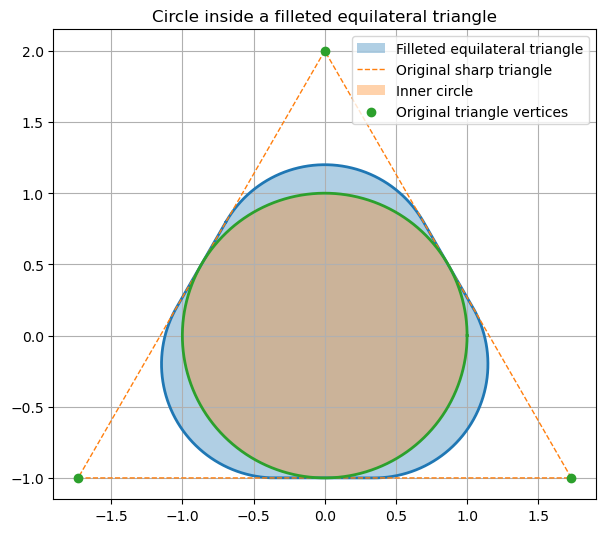

In [24]:

circle_radius = 1.0     # radius of the inner circle
fillet_radius = 0.8    # radius used to round / fillet each triangle point
resolution = 512        # curve smoothness

# -----------------------------
# VALIDATION
# -----------------------------

if circle_radius <= 0:
    raise ValueError("circle_radius must be positive.")

if fillet_radius < 0:
    raise ValueError("fillet_radius must be nonnegative.")

# For an equilateral triangle circumscribed around a circle:
# inradius = circle_radius
# side length = 2 sqrt(3) R
# circumradius = 2R

R_in = circle_radius
side_length = 2 * np.sqrt(3) * R_in
triangle_circumradius = 2 * R_in

# The maximum convex corner fillet radius is limited by the side length.
# For a 60-degree corner, tangent distance along each edge is:
#
#     t = fillet_radius / tan(30 deg)
#
# To fit, need 2t <= side_length.

max_fillet_radius = (side_length / 2) * np.tan(np.deg2rad(30))

if fillet_radius > max_fillet_radius:
    raise ValueError(
        f"fillet_radius too large. Max allowed is {max_fillet_radius:.6f}."
    )

# -----------------------------
# CONSTRUCT EQUILATERAL TRIANGLE
# -----------------------------

angles = np.deg2rad([90, 210, 330])

vertices = np.column_stack([
    triangle_circumradius * np.cos(angles),
    triangle_circumradius * np.sin(angles)
])

triangle = Polygon(vertices)

# -----------------------------
# FILLET THE TRIANGLE POINTS
# -----------------------------
# Shapely trick:
#
#   1. Erode polygon inward by fillet_radius.
#   2. Dilate it back outward by fillet_radius.
#
# This rounds sharp outside corners by fillet_radius while keeping
# the sides tangent to the original inner circle.

if fillet_radius == 0:
    filleted_triangle = triangle
else:
    filleted_triangle = triangle.buffer(
        -fillet_radius,
        resolution=resolution,
        join_style=2
    ).buffer(
        fillet_radius,
        resolution=resolution,
        join_style=1
    )

inner_circle = Point(0, 0).buffer(circle_radius, resolution=resolution)

# -----------------------------
# AREA CALCULATIONS
# -----------------------------

circle_area = inner_circle.area
filleted_triangle_area = filleted_triangle.area
area_difference = filleted_triangle_area - circle_area
percent_difference = 100 * area_difference / circle_area

print("Area Results")
print("-" * 40)
print(f"Circle radius              : {circle_radius:.8f}")
print(f"Fillet radius              : {fillet_radius:.8f}")
print(f"Triangle side length       : {side_length:.8f}")
print(f"Circle area                : {circle_area:.8f}")
print(f"Filleted triangle area     : {filleted_triangle_area:.8f}")
print(f"Area difference            : {area_difference:.8f}")
print(f"Percent difference         : {percent_difference:.4f}%")

# -----------------------------
# PLOT
# -----------------------------

fig, ax = plt.subplots(figsize=(7, 7))

# Filleted triangle
x, y = filleted_triangle.exterior.xy
ax.fill(x, y, alpha=0.35, label="Filleted equilateral triangle")
ax.plot(x, y, lw=2)

# Original sharp triangle for reference
x, y = triangle.exterior.xy
ax.plot(x, y, "--", lw=1, label="Original sharp triangle")

# Inner circle
x, y = inner_circle.exterior.xy
ax.fill(x, y, alpha=0.35, label="Inner circle")
ax.plot(x, y, lw=2)

# Vertices
ax.scatter(vertices[:, 0], vertices[:, 1], zorder=5, label="Original triangle vertices")

ax.set_aspect("equal")
ax.grid(True)
ax.legend()
ax.set_title("Circle inside a filleted equilateral triangle")

plt.show()

## Other options 
per chatGPT

Area comparison
----------------------------------------------------------------------
Option                                 Cavity area      Tube area     Difference
----------------------------------------------------------------------
Three drilled relief holes                5.853061       3.141573       2.711488
Three flat faces                          5.196152       3.141573       2.054579
Three cylindrical grooves                 7.123517       3.141573       3.981944
Reuleaux-like pocket                      4.124539       3.141573       0.982966
Rounded hexagon                           3.453652       3.141573       0.312079
Three tangent circular arcs               3.922747       3.141573       0.781174
Three V-grooves                           4.379251       3.141573       1.237678
Circular bore + reliefs                   4.362957       3.141573       1.221384
Three ball-end pockets                    4.077778       3.141573       0.936205
Filleted triangle               

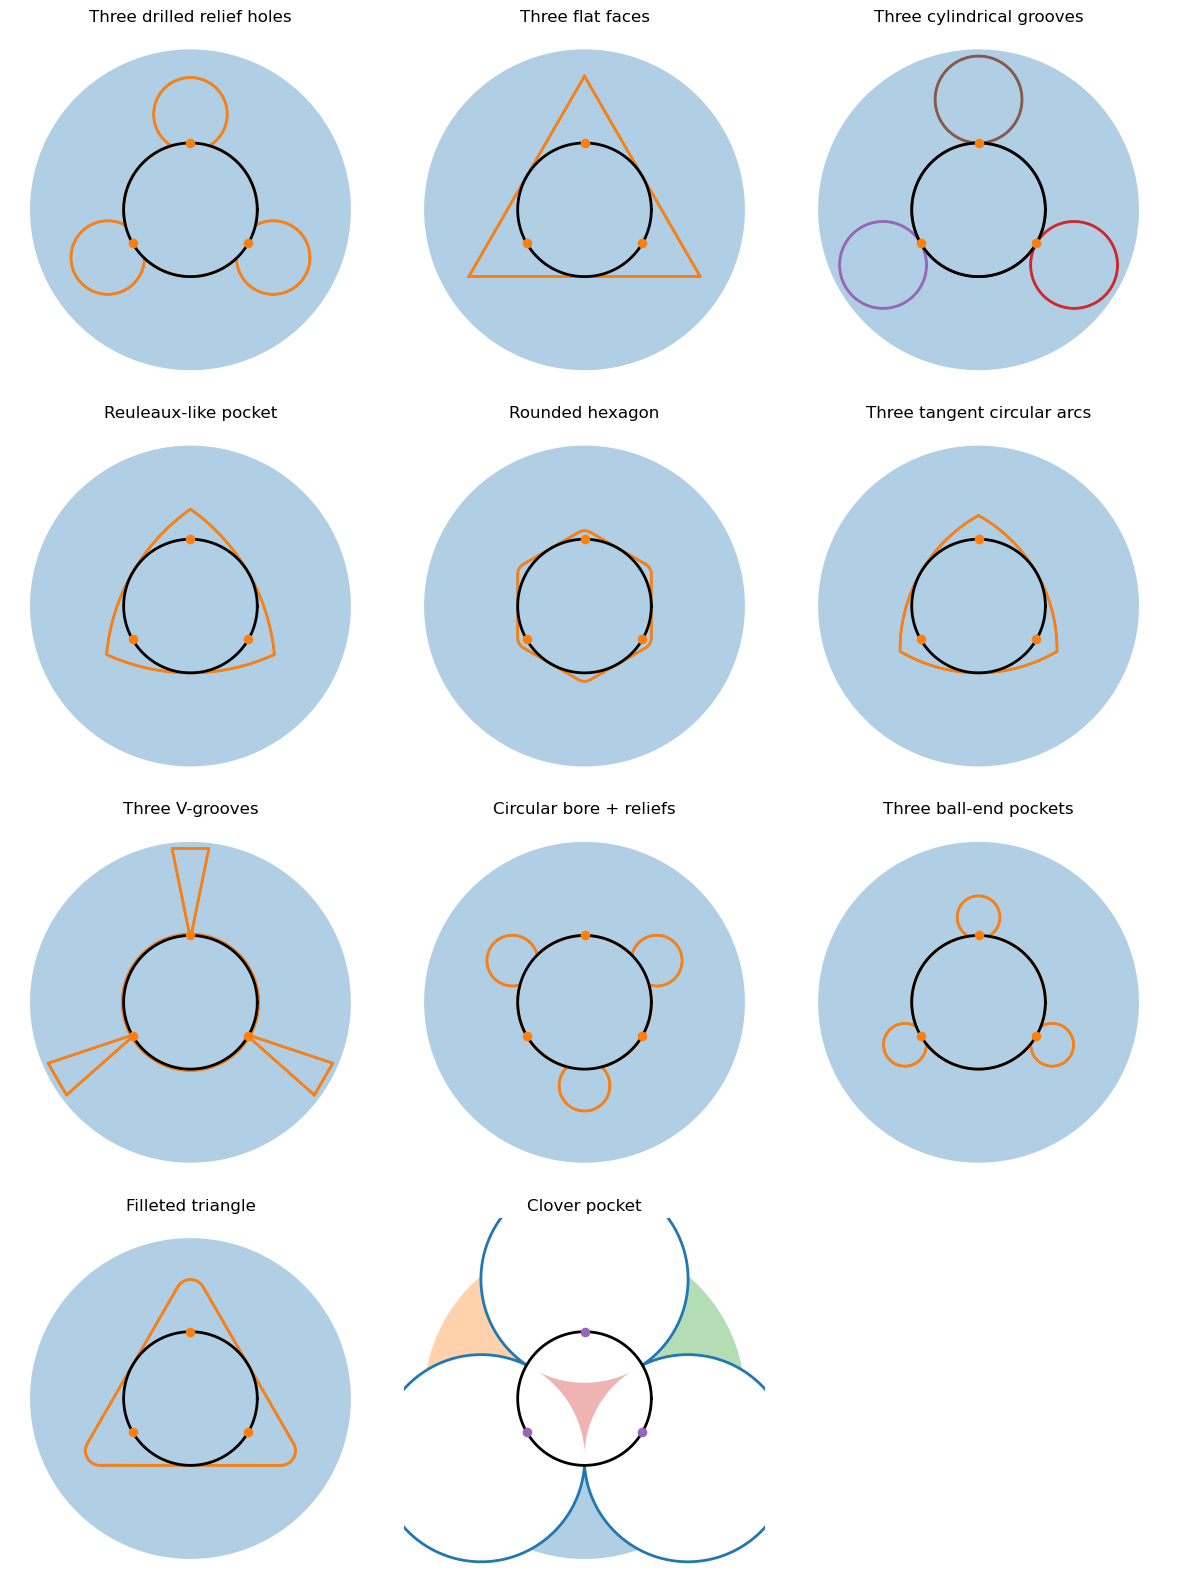

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon, box
from shapely.affinity import rotate, translate
from shapely.ops import unary_union

# ============================================================
# Visual comparison of manufacturable 3-contact tube mounts
# ============================================================

# Requires:
#   pip install numpy matplotlib shapely

# -----------------------------
# USER INPUTS
# -----------------------------

tube_radius = 1.0
clearance = 0.00

outer_block_radius = 2.4
resolution = 256

# plotting window
plot_limit = 2.7


# -----------------------------
# BASIC HELPERS
# -----------------------------

def disk(x, y, r):
    return Point(x, y).buffer(r, resolution=resolution)


def annular_block(inner_shape):
    """
    Represents the steel cross-section as a large circular block
    with the machined cavity removed.
    """
    block = disk(0, 0, outer_block_radius)
    return block.difference(inner_shape)


def plot_option(ax, cavity, title, contact_points=None):
    steel = annular_block(cavity)
    tube = disk(0, 0, tube_radius)

    # Steel
    if steel.geom_type == "Polygon":
        geoms = [steel]
    else:
        geoms = list(steel.geoms)

    for g in geoms:
        x, y = g.exterior.xy
        ax.fill(x, y, alpha=0.35)

        for hole in g.interiors:
            hx, hy = hole.xy
            ax.plot(hx, hy, linewidth=1.5)

    # Cavity outline
    if cavity.geom_type == "Polygon":
        geoms = [cavity]
    else:
        geoms = list(cavity.geoms)

    for g in geoms:
        x, y = g.exterior.xy
        ax.plot(x, y, linewidth=2)

    # Tube
    x, y = tube.exterior.xy
    ax.plot(x, y, "k", linewidth=2, label="Tube")

    # Contact points
    if contact_points is not None:
        contact_points = np.asarray(contact_points)
        ax.scatter(
            contact_points[:, 0],
            contact_points[:, 1],
            s=35,
            zorder=10
        )

    ax.set_aspect("equal")
    ax.set_xlim(-plot_limit, plot_limit)
    ax.set_ylim(-plot_limit, plot_limit)
    ax.set_title(title)
    ax.axis("off")


def regular_polygon(n, radius, rotation_deg=90):
    angles = np.deg2rad(rotation_deg + np.arange(n) * 360 / n)
    pts = np.column_stack([
        radius * np.cos(angles),
        radius * np.sin(angles)
    ])
    return Polygon(pts)


def contact_points_3(r=tube_radius):
    angles = np.deg2rad([90, 210, 330])
    return np.column_stack([
        r * np.cos(angles),
        r * np.sin(angles)
    ])


# ============================================================
# 1. Three drilled relief holes
# ============================================================

def cavity_three_drilled_reliefs():
    """
    A central bore plus three overlapping drilled relief holes.
    The remaining three lands are the intended contact regions.
    """
    base_radius = tube_radius + clearance
    base = disk(0, 0, base_radius)

    relief_radius = 0.55
    relief_center_radius = tube_radius + relief_radius * 0.78

    reliefs = []
    for ang in np.deg2rad([90, 210, 330]):
        reliefs.append(
            disk(
                relief_center_radius * np.cos(ang),
                relief_center_radius * np.sin(ang),
                relief_radius
            )
        )

    return unary_union([base] + reliefs)


# ============================================================
# 2. Three flat faces
# ============================================================

def cavity_three_flats():
    """
    An equilateral-triangle-like three-flat pocket.
    The circle touches one flat on each side.
    """
    # For three tangent flats around a circle, use an equilateral
    # triangle whose inradius equals tube_radius.
    inradius = tube_radius + clearance
    circumradius = 2 * inradius

    return regular_polygon(3, circumradius, rotation_deg=90)


# ============================================================
# 3. Three cylindrical grooves
# ============================================================

def cavity_three_cylindrical_grooves():
    """
    Three concave circular grooves arranged symmetrically.
    """
    base = disk(0, 0, tube_radius + clearance)

    groove_radius = 0.65
    groove_center_radius = tube_radius + groove_radius

    grooves = []
    for ang in np.deg2rad([90, 210, 330]):
        grooves.append(
            disk(
                groove_center_radius * np.cos(ang),
                groove_center_radius * np.sin(ang),
                groove_radius
            )
        )

    return unary_union([base] + grooves)


# ============================================================
# 4. Reuleaux-triangle-derived pocket
# ============================================================

def cavity_reuleaux_like():
    """
    Reuleaux-like three-arc pocket generated as the intersection
    of three large disks.
    """
    R = tube_radius
    arc_radius = 3.0 * R
    center_radius = arc_radius - R

    disks = []
    for ang in np.deg2rad([90, 210, 330]):
        disks.append(
            disk(
                center_radius * np.cos(ang),
                center_radius * np.sin(ang),
                arc_radius
            )
        )

    return disks[0].intersection(disks[1]).intersection(disks[2])


# ============================================================
# 5. Rounded hexagon
# ============================================================

def cavity_rounded_hexagon():
    """
    Hexagonal pocket with rounded vertices.
    """
    inradius = tube_radius + clearance
    circumradius = inradius / np.cos(np.pi / 6)

    hexagon = regular_polygon(6, circumradius, rotation_deg=30)

    fillet = 0.18
    return hexagon.buffer(-fillet, resolution=resolution).buffer(
        fillet,
        resolution=resolution
    )


# ============================================================
# 6. Three tangent circular arcs
# ============================================================

def cavity_three_tangent_arcs():
    """
    Pocket made from three tangent circular arcs.
    """
    arc_radius = 2.3 * tube_radius
    center_radius = arc_radius - tube_radius

    disks_for_intersection = []

    for ang in np.deg2rad([90, 210, 330]):
        disks_for_intersection.append(
            disk(
                center_radius * np.cos(ang),
                center_radius * np.sin(ang),
                arc_radius
            )
        )

    cavity = disks_for_intersection[0]
    for d in disks_for_intersection[1:]:
        cavity = cavity.intersection(d)

    return cavity


# ============================================================
# 7. Three V-grooves
# ============================================================

def cavity_three_v_grooves():
    """
    A simple approximation of three V-groove seats.
    """
    base = disk(0, 0, tube_radius + 0.02)

    grooves = []

    for ang_deg in [90, 210, 330]:
        length = 1.3
        width = 0.55

        tri = Polygon([
            [0, tube_radius * 0.95],
            [-width / 2, tube_radius + length],
            [ width / 2, tube_radius + length],
        ])

        grooves.append(rotate(tri, ang_deg - 90, origin=(0, 0)))

    return unary_union([base] + grooves)


# ============================================================
# 8. Circular bore with three relief pockets
# ============================================================

def cavity_bore_with_reliefs():
    """
    Round bore with three local relief pockets.
    This leaves three intended contact lands.
    """
    bore = disk(0, 0, tube_radius + clearance)

    reliefs = []
    relief_radius = 0.38
    relief_center_radius = tube_radius + relief_radius * 0.65

    for ang in np.deg2rad([30, 150, 270]):
        reliefs.append(
            disk(
                relief_center_radius * np.cos(ang),
                relief_center_radius * np.sin(ang),
                relief_radius
            )
        )

    return unary_union([bore] + reliefs)


# ============================================================
# 9. Three spherical / ball-end pockets in cross section
# ============================================================

def cavity_three_ball_end_pockets():
    """
    Cross-section view of three ball-end-milled pockets.
    Similar to local round reliefs.
    """
    base = disk(0, 0, tube_radius + clearance)

    pocket_radius = 0.32
    pocket_center_radius = tube_radius + pocket_radius * 0.85

    pockets = []

    for ang in np.deg2rad([90, 210, 330]):
        pockets.append(
            disk(
                pocket_center_radius * np.cos(ang),
                pocket_center_radius * np.sin(ang),
                pocket_radius
            )
        )

    return unary_union([base] + pockets)


# ============================================================
# 10. Rounded / filleted equilateral triangle
# ============================================================

def cavity_filleted_triangle():
    """
    Equilateral triangle circumscribed around the tube, with
    rounded corners.
    """
    inradius = tube_radius + clearance
    circumradius = 2 * inradius

    tri = regular_polygon(3, circumradius, rotation_deg=90)

    fillet_radius = 0.22

    return tri.buffer(-fillet_radius, resolution=resolution).buffer(
        fillet_radius,
        resolution=resolution
    )


# ============================================================
# 11. Clover / three-lobed pocket
# ============================================================

def cavity_clover():
    """
    Three overlapping circles forming a clover-like pocket.
    """
    clover_circle_radius = 1.55 * tube_radius

    # Place centers so the inner cusps lie near the tube.
    a = 0.5 * (
        tube_radius
        + np.sqrt(4 * clover_circle_radius**2 - 3 * tube_radius**2)
    )

    lobes = []

    for ang in np.deg2rad([90, 210, 330]):
        lobes.append(
            disk(
                a * np.cos(ang),
                a * np.sin(ang),
                clover_circle_radius
            )
        )

    return unary_union(lobes)


# ============================================================
# COLLECT OPTIONS
# ============================================================

options = [
    ("Three drilled relief holes", cavity_three_drilled_reliefs()),
    ("Three flat faces", cavity_three_flats()),
    ("Three cylindrical grooves", cavity_three_cylindrical_grooves()),
    ("Reuleaux-like pocket", cavity_reuleaux_like()),
    ("Rounded hexagon", cavity_rounded_hexagon()),
    ("Three tangent circular arcs", cavity_three_tangent_arcs()),
    ("Three V-grooves", cavity_three_v_grooves()),
    ("Circular bore + reliefs", cavity_bore_with_reliefs()),
    ("Three ball-end pockets", cavity_three_ball_end_pockets()),
    ("Filleted triangle", cavity_filleted_triangle()),
    ("Clover pocket", cavity_clover()),
]

# ============================================================
# AREA REPORT
# ============================================================

tube = disk(0, 0, tube_radius)
tube_area = tube.area

print("Area comparison")
print("-" * 70)
print(f"{'Option':35s} {'Cavity area':>14s} {'Tube area':>14s} {'Difference':>14s}")
print("-" * 70)

for name, cavity in options:
    cavity_area = cavity.area
    diff = cavity_area - tube_area
    print(f"{name:35s} {cavity_area:14.6f} {tube_area:14.6f} {diff:14.6f}")

# ============================================================
# PLOT ALL OPTIONS
# ============================================================

ncols = 3
nrows = int(np.ceil(len(options) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

contacts = contact_points_3(tube_radius)

for ax, (name, cavity) in zip(axes, options):
    plot_option(ax, cavity, name, contact_points=contacts)

for ax in axes[len(options):]:
    ax.axis("off")

plt.tight_layout()
plt.show()